# An interpretable P(start) model for Fantasy Premier League

**The problem.** Every week, more than 11 million Fantasy Premier League managers choose transfers, a starting eleven and a captain before a deadline. Almost everything a player can score depends on his minutes, and his minutes depend above all on whether he **starts**. A player who is benched, rotated or quietly injured scores little or nothing, and a manager who bought or captained him loses points they cannot recover. The single most useful number before a deadline is therefore the probability that each player starts his club's next match. FPL's own availability flag does not provide it: it says whether a player *can* be picked, not whether his manager *will* pick him.

**Why a general-purpose assistant is not enough on its own.** Many managers now ask assistants such as Claude or ChatGPT for help with exactly these questions ("will he start?", "who should I captain?"). On its own, an assistant answers from its training data and whatever is in the conversation. Training data is out of date by the time a deadline arrives and does not contain this week's injury flags or last weekend's team sheets, and the assistant has no calibrated way to turn "he was taken off at half-time" into a probability. The answer can sound confident while resting on stale or partial evidence.

**How this project approaches it.** It separates the two jobs:

1. **A statistical modelling layer** (this model) turns current data into a calibrated P(start): FPL's injury and availability flags as they stood before each deadline, and each player's recent playing record. Every prediction is stored with the exact arithmetic behind it.
2. **A conversational layer** (the next step, section 16) answers questions by reading those stored numbers instead of relying on its own memory.

The language model then explains a number grounded in better data, rather than inventing one.

This notebook covers the first layer: how the model was designed, validated and frozen, and how any single prediction can be taken apart into its reasons. The implementation lives in `src/fpl_starts/ml/`. The operational reference (commands, outputs, rules) is [`docs/logistic_p_start_model.md`](../docs/logistic_p_start_model.md), and the full audit trail of modelling decisions is [`docs/logistic_p_start_modelling_log.md`](../docs/logistic_p_start_modelling_log.md).

The notebook does not fit the production model. It reads the persisted outputs:

| Output | Produced by |
|---|---|
| frozen model (`model.json`) | `fpl-starts-logistic-train`, run once |
| historical walk-forward results | `fpl-starts-logistic-evaluate` |
| aggregate case-study analyses (correlations, VIFs, comparison fits) | `fpl-starts-logistic-case-study` |
| 2026-27 prediction snapshots | `fpl-starts-logistic-predict`, one per gameweek |

The historical inputs are local-only and not distributed with this repository, so the outputs below are rendered from a local run. Every output shown is aggregate (metrics, correlations, coefficients) or a single stored prediction; no historical data rows are included.

In [1]:
import hashlib
from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.io as pio

from fpl_starts.ml import spec
from fpl_starts.research import logistic_case_study as cs

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_DIR = ROOT / "models" / spec.MODEL_VERSION / spec.MODEL_ID
MODEL_PATH = MODEL_DIR / "model.json"

model = cs.load_json(MODEL_PATH)
history = cs.load_json(MODEL_DIR / "historical_evaluation.json")
study = cs.load_json(ROOT / cs.CASE_STUDY_PATH)
snapshots = cs.load_snapshots(ROOT / "predictions")
names = cs.player_names(ROOT / "db" / "derived.db")

# Presentation: interactive figures in Jupyter, a static PNG for GitHub.
pio.renderers.default = "plotly_mimetype+png"
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"
RED, NEUTRAL, INK, INK2, GRID, SURFACE = "#e34948", "#a3a29c", "#0b0b0b", "#52514e", "#e7e6e2", "#fcfcfb"
pio.templates["case_study"] = pio.templates["plotly_white"]
pio.templates["case_study"].layout.update(
    font=dict(family="Inter, Helvetica, Arial, sans-serif", size=13, color=INK2),
    title=dict(font=dict(size=16, color=INK)), paper_bgcolor=SURFACE, plot_bgcolor=SURFACE,
    xaxis=dict(gridcolor=GRID, zerolinecolor=NEUTRAL, linecolor=GRID),
    yaxis=dict(gridcolor=GRID, zerolinecolor=NEUTRAL, linecolor=GRID),
    margin=dict(l=20, r=20, t=60, b=40))
pio.templates.default = "case_study"

LABELS = {
    "availability_status__doubtful_75": "Doubtful: 75%",
    "availability_status__doubtful_50": "Doubtful: 50%",
    "availability_status__doubtful_25": "Doubtful: 25%",
    "availability_status__injured": "Injured",
    "availability_status__suspended": "Suspended",
    "availability_status__unavailable": "Unavailable (left club, on loan)",
    "availability_status__unknown": "No availability record",
    "last_gw_role__sub_appearance": "Sub appearance last GW",
    "last_gw_role__started_under_60": "Started, under 60 min last GW",
    "last_gw_role__started_60_plus": "Started 60+ last GW",
    "minutes_prior_3_gws": "Minutes in the 3 GWs before last",
    "current_season_start_rate": "Current-season start rate",
    "previous_season_start_rate": "Previous-season start rate",
    "no_previous_season": "No previous PL season",
    "first_game_at_club": "First game at club",
}

In [2]:
# The frozen artefact everything below refers to.
meta = model["metadata"]
pd.Series({
    "model id": model["model_id"],
    "created (UTC)": meta["created_at"],
    "training seasons": ", ".join(meta["training_seasons"]),
    "training rows": f'{meta["training_rows"]:,}',
    "regularisation": f'L2, C = {model["regularisation"]["C"]:g}',
    "coefficients": f'{len(model["transformed_features"])} + intercept',
    "model.json sha256": hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest(),
}, name="").to_frame()

,
model id,logistic_availability_v1
created (UTC),2026-09-24T16:40:04Z
training seasons,"2023-24, 2024-25, 2025-26"
training rows,"86,755"
regularisation,"L2, C = 10"
coefficients,15 + intercept
model.json sha256,64ff2465a5a3f3ceec5313c4ccaf897c1cd35574eff6e7...


## 1. The prediction problem

> Before each Fantasy Premier League deadline, estimate the probability that each player will start.

Why that number matters:

- **Expected FPL points depend heavily on minutes**, and minutes depend heavily on whether a player starts. A substitute appearance is worth a fraction of a start.
- **Injury flags alone are not enough.** FPL's `chance_of_playing` says whether a player *can* be picked, not whether his manager *will* pick him. Rotation, form and squad depth decide that.
- **Different players need different probabilities.** A nailed-on starter, a rotation player and someone returning from injury can all be "available" and still have very different chances of starting.

## 2. Temporal design and leakage control

A model that is evaluated on data it has, in any way, already seen gives optimistic results. The design keeps a strict separation in time.

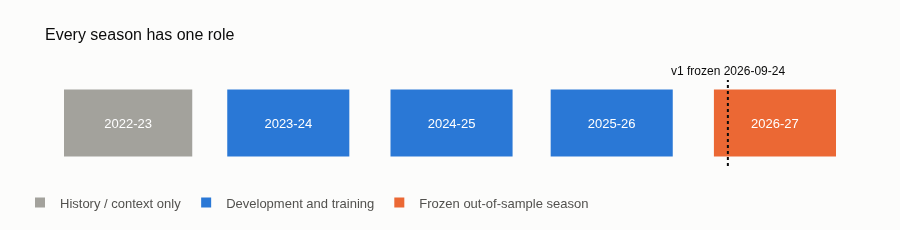

In [3]:
seasons = pd.DataFrame([
    ("2022-23", "2022-08-05", "2023-05-28", "History / context only"),
    ("2023-24", "2023-08-11", "2024-05-19", "Development and training"),
    ("2024-25", "2024-08-16", "2025-05-25", "Development and training"),
    ("2025-26", "2025-08-15", "2026-05-24", "Development and training"),
    ("2026-27", "2026-08-21", "2027-05-30", "Frozen out-of-sample season"),
], columns=["season", "start", "end", "role"])
seasons["row"] = "Season"

fig = px.timeline(seasons, x_start="start", x_end="end", y="row", color="role", text="season",
                  color_discrete_map={"History / context only": NEUTRAL,
                                      "Development and training": BLUE,
                                      "Frozen out-of-sample season": ORANGE},
                  title="Every season has one role")
fig.update_traces(textposition="inside", insidetextanchor="middle", textfont_color="white", marker_line_width=2,
                  marker_line_color=SURFACE)
fig.add_vline(x=meta["created_at"][:10], line_dash="dot", line_color=INK)
fig.add_annotation(x=meta["created_at"][:10], y=1.0, yref="paper", yanchor="bottom",
                   text="v1 frozen 2026-09-24", showarrow=False, font=dict(color=INK, size=12))
fig.update_yaxes(visible=False)
fig.update_xaxes(title=None, showgrid=False, showticklabels=False)
fig.update_layout(height=230, width=900, margin=dict(t=80), legend=dict(title=None, orientation="h", y=-0.25, x=0))
fig

- **2022-23 is history only.** It is the first season in the data, so its rows have no previous-season record and, early on, every player looks like a new arrival at his club. Those are artefacts of where the data starts, not football. The season only supplies lagged history (previous-season role, recent form) for 2023-24.
- **Training rows begin in 2023-24.** 2023-24 to 2025-26 were used to choose the features, pick the regularisation strength and fit the model. Because 2024-25 and 2025-26 informed those choices, their results are described as *development* results, never as an untouched test.
- **2026-27 was excluded from everything.** No feature choice, tuning or fitting used it. The model was frozen on 2026-09-24, before any 2026-27 prediction was scored.
- **v1 is never overwritten.** An improved model gets a new model id and builds its own prospective record.

**Point-in-time features.** Every feature for gameweek *N* uses only information available before *N*'s prediction cutoff (two hours before the deadline): outcomes from gameweeks strictly before *N*, and the latest availability flag recorded before the cutoff. Both fixtures of a double gameweek share one feature vector, so one fixture's outcome can never inform the other.

## 3. Starting from a large candidate feature set

The initial research looked at many overlapping measures of a player's role and availability. Grouped by the football concept they describe:

In [4]:
concepts = {
    "Started recently": ["prev_started", "consecutive_starts"],
    "Recent starts / start rates": ["starts_last_2", "starts_last_4", "starts_last_10",
                                    "start_rate_last_4", "start_rate_last_10"],
    "Recent minutes": ["minutes_last_1", "minutes_last_2", "minutes_last_4", "minutes_last_10",
                       "minutes_prior_3_gws"],
    "Current-season role": ["current_season_starts", "current_season_start_rate"],
    "Previous-season role": ["previous_season_starts", "previous_season_minutes", "previous_season_start_rate"],
    "Structured availability": ["chance_of_playing", "is_available"],
}
pd.DataFrame([(c, f, study["candidates"][f]) for c, fs in concepts.items() for f in fs],
             columns=["concept", "candidate", "meaning"]).set_index(["concept", "candidate"])

meaning
concept                     candidate                                                                    
Started recently            prev_started                                    started his previous gameweek
                            consecutive_starts              run of consecutive starts up to last gameweek
Recent starts / start rates starts_last_2                                  starts in the last 2 gameweeks
                            starts_last_4                                  starts in the last 4 gameweeks
                            starts_last_10                                starts in the last 10 gameweeks
                            start_rate_last_4                       share of the last 4 gameweeks started
                            start_rate_last_10                     share of the last 10 gameweeks started
Recent minutes              minutes_last_1                                          minutes last gameweek
                            minutes_last_2                                minutes in the last 2 gameweeks
                            minutes_last_4                                minutes in the last 4 gameweeks
                            minutes_last_10                              minutes in the last 10 gameweeks
                            minutes_prior_3_gws                    minutes in the 3 gameweeks before last
Current-season role         current_season_starts                               starts so far this season
                            current_season_start_rate            share of this season's gameweeks started
Previous-season role        previous_season_starts                                     starts last season
                            previous_season_minutes                                   minutes last season
                            previous_season_start_rate           share of last season's gameweeks started
Structured availability     chance_of_playing           FPL chance of playing next round (100 when ava...
                            is_available                                          FPL status is available

Club-change history (a first-game-at-club flag) and FPL's categorical availability status complete the set. Every candidate is computed from gameweeks strictly before the one being predicted, within the player's spell at his current club.

A large feature set like this can be handed to a regularised model and left to sort itself out. For a model whose job is to *explain* its predictions, that is the wrong trade-off, as the next section shows.

## 4. Collinearity and simplification

Many candidates measure almost the same thing. Rank correlations on the 86,755 development-season rows:

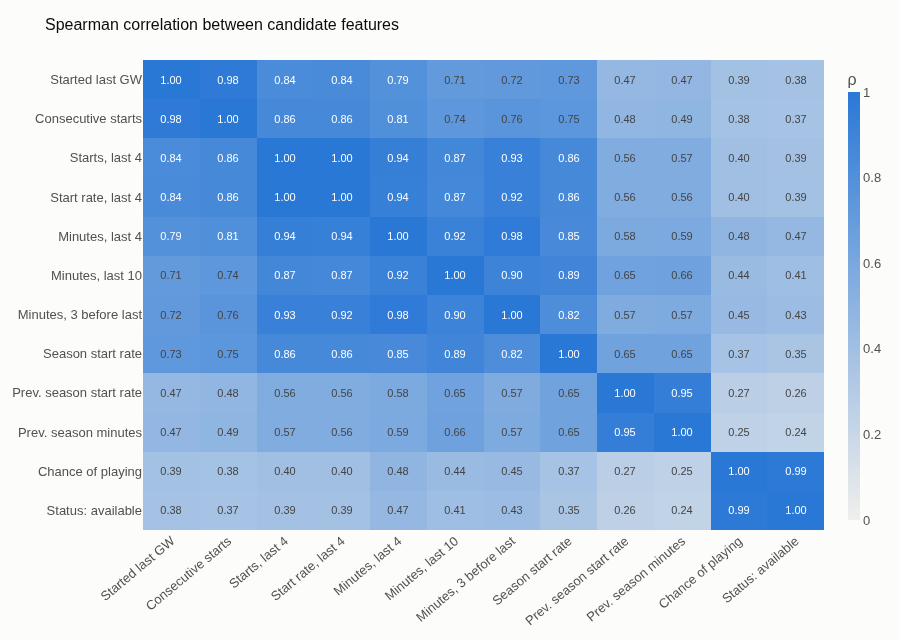

In [5]:
red = study["redundancy"]
short = {
    "prev_started": "Started last GW", "consecutive_starts": "Consecutive starts",
    "starts_last_4": "Starts, last 4", "start_rate_last_4": "Start rate, last 4",
    "minutes_last_4": "Minutes, last 4", "minutes_last_10": "Minutes, last 10",
    "minutes_prior_3_gws": "Minutes, 3 before last", "current_season_start_rate": "Season start rate",
    "previous_season_start_rate": "Prev. season start rate", "previous_season_minutes": "Prev. season minutes",
    "chance_of_playing": "Chance of playing", "is_available": "Status: available",
}
labels = [short[f] for f in red["heatmap_features"]]
corr = pd.DataFrame(red["heatmap"], index=labels, columns=labels)
fig = px.imshow(corr, text_auto=".2f", zmin=0, zmax=1, aspect="auto",
                color_continuous_scale=[(0, "#f0efec"), (1, BLUE)],
                title="Spearman correlation between candidate features")
fig.update_traces(textfont_size=11)
fig.update_xaxes(tickangle=-40, side="bottom")
fig.update_layout(height=640, width=900, coloraxis_colorbar=dict(title="ρ", thickness=12))
fig

In [6]:
pairs = pd.DataFrame(red["highlighted_pairs"])
pairs["pair"] = pairs["a"] + "  vs  " + pairs["b"]
pairs.set_index("pair")[["spearman"]].style.format("{:.3f}")

,spearman
pair,
starts_last_4 vs start_rate_last_4,0.998
minutes_last_2 vs minutes_last_4,0.939
minutes_last_4 vs minutes_last_10,0.919
previous_season_starts vs previous_season_start_rate,0.989
previous_season_minutes vs previous_season_start_rate,0.946
prev_started vs consecutive_starts,0.981
chance_of_playing vs is_available,0.991


Several of these are near-duplicates (ρ ≈ 0.92–0.998), and some are exact linear combinations of others. For example, minutes over the last four gameweeks is exactly last week's minutes plus the three weeks before. Put them all in one logistic regression and the fit still works, but the individual coefficients stop meaning anything.

To show what that costs and what it buys, the same walk-forward evaluation was run with **every candidate at once** (31 coefficients) and with the **compact six-concept model** (15 coefficients):

In [7]:
specs = study["specifications"]
n0 = specs["frozen"]["naive"]["overall"]["brier"]
full_brier = specs["full_candidate_set"]["logistic"]["overall"]["brier"]
def unstable(s):
    a, b = s["coefficients_by_fold"]["2024-25"], s["coefficients_by_fold"]["2025-26"]
    return f'{sum(abs(a[k] - b[k]) > 0.3 * max(abs(a[k]), abs(b[k])) for k in a)} of {len(a)}'
def spec_row(s):
    o = s["logistic"]["overall"]
    return {"Brier": o["brier"], "Rotation Brier": o["rotation_brier"], "calibration slope": o["calibration_slope"],
            "ECE": o["ece"], "coefficients": s["n_coefficients"], "max VIF": s["max_vif"],
            "share of improvement over naive": (n0 - o["brier"]) / (n0 - full_brier),
            "coefficients changing >30% between folds": unstable(s)}
pd.DataFrame({"All candidates": spec_row(specs["full_candidate_set"]),
              "Compact model (v1)": spec_row(specs["frozen"])}).T.style.format(
    {"Brier": "{:.5f}", "Rotation Brier": "{:.5f}", "calibration slope": "{:.3f}", "ECE": "{:.4f}",
     "coefficients": "{:.0f}", "max VIF": "{:.1f}", "share of improvement over naive": "{:.1%}"})

,Brier,Rotation Brier,calibration slope,ECE,coefficients,max VIF,share of improvement over naive,coefficients changing >30% between folds
All candidates,0.07608,0.15180,0.986,0.0144,31,inf,100.0%,14 of 31
Compact model (v1),0.07825,0.15574,0.961,0.0175,15,4.0,92.1%,0 of 15


In [8]:
# What the coefficients look like when everything is in (fold testing 2025-26).
full = specs["full_candidate_set"]["coefficients_by_fold"]["2025-26"]
compact = specs["frozen"]["coefficients_by_fold"]["2025-26"]
show = ["availability_status__doubtful_75", "availability_status__injured",
        "last_gw_role__started_60_plus", "last_gw_role__started_under_60", "starts_last_4"]
pd.DataFrame({"feature": [LABELS.get(f, "Starts in last 4 GWs (per SD)") for f in show],
              "all candidates": [full[f] for f in show],
              "compact model": [compact.get(f) for f in show]}).set_index("feature").style.format("{:+.2f}", na_rep="not in model")

,all candidates,compact model
feature,,
Doubtful: 75%,+0.71,-0.83
Injured,+0.11,-4.36
Started 60+ last GW,+0.07,+2.30
"Started, under 60 min last GW",-0.28,+0.81
Starts in last 4 GWs (per SD),-0.29,not in model


With every candidate included:

- **Being flagged doubtful (75%) or injured *raises* the log-odds of starting.** The numeric chance-of-playing field has absorbed the availability effect, and the status dummies are left fitting noise around it.
- **"Started 60+ last GW" collapses to almost zero and a short start turns negative**, because last week's minutes and starts are counted in four other columns.
- **Starts in the last four gameweeks gets a negative coefficient.** No one would explain a prediction that way.
- Several columns have an **infinite VIF**: they are exact linear combinations of other columns.

**The trade-off.** The larger candidate model achieved better predictive performance: its Brier score is **0.0022 lower** overall (0.07608 vs 0.07825, 2.9%) and **0.0039 lower** in the Rotation stratum (2.6%). That is a real gain. It came at the cost of severe multicollinearity and counter-intuitive coefficients.

The compact model retained about **92%** of the full model's improvement over the naive baseline (90% in the Rotation stratum), while producing substantially more stable and interpretable coefficients: between the two folds, none of its 15 coefficients changes by more than 30%, against 14 of the full model's 31.

**The decision:**

> Rather than rely on regularisation to manage a large set of redundant variables, the public model keeps one clear predictor for each football concept.

## 5. The final model

Six conceptual predictors:

| Concept | Model variable | Interpretation |
|---|---|---|
| Availability | `availability_status` | available, doubtful (75/50/25%), injured, suspended, unavailable, no record |
| Last gameweek | `last_gw_role` | did not play, substitute, short start (< 60 min), 60+ start |
| Recent playing time | `minutes_prior_3_gws` | minutes in the three gameweeks before last week |
| Current-season role | `current_season_start_rate` | how established the player is this season |
| Previous-season role | `previous_season_start_rate` + `no_previous_season` | last season's role, with a flag when there was none |
| New club | `first_game_at_club` | no prior evidence at his current club |

The two categorical predictors expand into dummy columns against a reference level (7 availability levels against *available*, 3 roles against *did not play*), so the model has **15 coefficients plus an intercept**:

In [9]:
pd.DataFrame({"model column": model["transformed_features"],
              "label": [LABELS[f] for f in model["transformed_features"]]}).set_index("model column")

,label
model column,
availability_status__doubtful_75,Doubtful: 75%
availability_status__doubtful_50,Doubtful: 50%
availability_status__doubtful_25,Doubtful: 25%
availability_status__injured,Injured
availability_status__suspended,Suspended
availability_status__unavailable,"Unavailable (left club, on loan)"
availability_status__unknown,No availability record
last_gw_role__sub_appearance,Sub appearance last GW
last_gw_role__started_under_60,"Started, under 60 min last GW"


## 6. Why minutes from the *prior three* gameweeks?

Recent playing time could have been measured two ways, alongside `last_gw_role`:

```text
last_gw_role + minutes_prior_3_gws     (chosen)
last_gw_role + minutes_last_4
```

`minutes_last_4` includes last week, which `last_gw_role` already describes. Everything else identical, same folds, on the public panel:

In [10]:
a, b = specs["frozen"], specs["minutes_last_4"]
rows = {}
for window in ["overall", "2024-25", "2025-26"]:
    for label, s in [("minutes_prior_3_gws", a), ("minutes_last_4", b)]:
        m = s["logistic"][window]
        rows[(window, label)] = {"Brier": m["brier"], "Rotation Brier": m["rotation_brier"],
                                 "calibration slope": m["calibration_slope"], "ECE": m["ece"]}
table = pd.DataFrame(rows).T
table.style.format({"Brier": "{:.5f}", "Rotation Brier": "{:.5f}", "calibration slope": "{:.3f}", "ECE": "{:.4f}"})

In [11]:
oa, ob = a["logistic"]["overall"], b["logistic"]["overall"]
pd.Series({
    "Brier difference (chosen − alternative)": f'{oa["brier"] - ob["brier"]:+.5f}',
    "relative": f'{oa["brier"] / ob["brier"] - 1:+.1%}',
    "Rotation Brier difference": f'{oa["rotation_brier"] - ob["rotation_brier"]:+.5f}',
    "max VIF (chosen vs alternative)": f'{a["max_vif"]:.1f} vs {b["max_vif"]:.1f}',
    "coefficients": f'{a["n_coefficients"]} vs {b["n_coefficients"]}',
    "sign flips across folds": f'{len(a["sign_flips_across_folds"])} vs {len(b["sign_flips_across_folds"])}',
}, name="").to_frame()

,
Brier difference (chosen − alternative),+0.00041
relative,+0.5%
Rotation Brier difference,+0.00110
max VIF (chosen vs alternative),4.0 vs 5.9
coefficients,15 vs 15
sign flips across folds,0 vs 0


The alternative is better by **0.00041 Brier** overall (about 0.5%) and **0.00110** in the Rotation stratum, consistently in both test seasons. The chosen version keeps a clean separation of three things an explanation needs to tell apart:

1. what happened last gameweek;
2. playing time in the three gameweeks before that;
3. the player's role across the season.

With `minutes_last_4`, last week is counted twice: its maximum VIF rises from 4.0 to 5.9, and the `last_gw_role` coefficients shrink (a 60+ start drops from about 2.35 to 1.89) because the effect is split between two terms. A four-ten-thousandths gain in Brier is not worth an explanation that double-counts. This is a deliberate choice of interpretability over a negligible predictive gain.

## 7. Preprocessing

Only the preprocessing that matters for reading coefficients:

**Continuous variables** are standardised with the training mean and standard deviation, $z = (x - \bar{x}) / s$, so a coefficient is the change in log-odds for a **one-standard-deviation** increase. A missing value (for example no games yet this season) is replaced by the training mean, so $z = 0$ and it contributes nothing to the prediction.

**Missingness** carries meaning only where football gives it one. There are no generic "was missing" indicators; the two flags are `no_previous_season` and `first_game_at_club`, and they carry the "no history" effect.

**Categorical variables** use explicit reference levels. For example, the coefficient for *Doubtful: 50%* is read relative to an *available* player, and *Started 60+ last GW* relative to a player who *did not play*.

**The model** is an L2-regularised logistic regression,

$$\text{logit}\,P(\text{start}) = \beta_0 + \sum_j \beta_j x_j,$$

with the regularisation strength $C$ chosen by chronological validation (trained on 2023-24 and 2024-25, scored on 2025-26), then refitted on all three training seasons. The validation curve is flat above $C = 1$, and $C = 10$ was selected.

Every statistic is learned from training rows only, and inside each historical fold it is re-learned from that fold's training window.

In [12]:
pre = model["preprocessing"]["continuous"]
pd.DataFrame({LABELS[c]: {"training mean": v["training_mean"], "training SD": v["training_sd"]}
              for c, v in pre.items()}).T.style.format("{:.3f}")

,training mean,training SD
Current-season start rate,0.298,0.356
Minutes in the 3 GWs before last,78.879,104.813
Previous-season start rate,0.328,0.257


## 8. Measuring performance: the Brier score, and why one number is not enough

The **Brier score** is the mean squared difference between the predicted probability and what happened (1 if the player started, 0 if not):

$$\text{Brier} = \frac{1}{N}\sum_{i=1}^{N} (p_i - y_i)^2 .$$

Lower is better, and a perfect forecaster scores 0. Because starts are imbalanced (about 29% of player-gameweeks in the test seasons are starts), the useful reference is not a coin toss: a forecaster that knows nothing about the player and always predicts the overall start rate $r$ scores $r(1-r) \approx 0.207$. (Always saying 50% scores 0.25 whatever the start rate, which makes it too easy a reference to beat.) The Brier score is a *proper* scoring rule, so a forecaster gets the best expected score by reporting its honest probability. It rewards probabilities that are both sharp and calibrated, and it is the headline metric throughout.

**Why one pooled number misleads.** Many player-gameweeks are close to certain. A squad player who has not started all season almost never starts next week, and any sensible model predicts that. These easy rows are a large part of the data, so a Brier score pooled over every row is dominated by them. Two models can look similar overall while differing a lot on the players where the starting decision is genuinely uncertain, which is where the forecast matters for FPL choices.

**Strata.** Each player-gameweek is labelled from the player's record so far this season, using only gameweeks before the one being predicted:

| Stratum | Share of this season's gameweeks started so far |
|---|---|
| Core | 50% or more |
| Rotation | 15% to under 50% |
| Marginal | more than 0, under 15% |
| Deep | none: never started this season, including a player's first gameweek of the season, before there is any record |

These are evaluation labels only; the model never sees them. The denominator is gameweeks the player was registered for, so an injured regular drifts down the strata while he is out.

Out-of-fold predictions on the two development test seasons (2024-25 and 2025-26):

In [13]:
perf = study["performance_by_player_type"]
def player_type_table(rows, label):
    t = pd.DataFrame(rows).rename(columns={
        "group": label, "share_of_rows": "share of rows", "start_rate": "observed start rate",
        "base_rate_brier": "group-average Brier", "brier_naive": "benchmark Brier",
        "brier_logistic": "logistic Brier", "share_of_squared_error_logistic": "share of logistic error"})
    return t.set_index(label).drop(columns="n").style.format({
        "share of rows": "{:.1%}", "observed start rate": "{:.1%}", "group-average Brier": "{:.4f}",
        "benchmark Brier": "{:.4f}", "logistic Brier": "{:.4f}", "share of logistic error": "{:.1%}"})
player_type_table(perf["by_stratum"], "stratum")

,share of rows,observed start rate,group-average Brier,benchmark Brier,logistic Brier,share of logistic error
stratum,,,,,,
Core,29.7%,71.7%,0.2028,0.1695,0.1190,45.1%
Rotation,15.5%,34.2%,0.2251,0.1920,0.1557,30.9%
Marginal,7.5%,14.0%,0.1206,0.1154,0.0946,9.0%
Deep,47.4%,3.6%,0.0345,0.0319,0.0247,15.0%


*Group-average Brier* is what a forecaster would score if it knew only which group the player is in and always predicted that group's start rate, $r(1-r)$. It measures how uncertain each group is to begin with. *Share of logistic error* is each group's share of the model's total squared error.

Splitting the strata more finely, by the share of games started so far, shows where the difficulty actually sits:

In [14]:
player_type_table(perf["by_band"], "start record this season")

,share of rows,observed start rate,group-average Brier,benchmark Brier,logistic Brier,share of logistic error
start record this season,,,,,,
No gameweek yet this season,2.9%,28.7%,0.2046,0.1699,0.1365,5.0%
Never started this season,44.5%,2.0%,0.0193,0.0231,0.0176,10.0%
Started under 15%,7.5%,14.0%,0.1206,0.1154,0.0946,9.0%
Started 15-50%,15.5%,34.2%,0.2251,0.1920,0.1557,30.9%
Started 50-90%,18.5%,62.0%,0.2357,0.1990,0.1444,34.2%
Started 90%+,11.1%,88.0%,0.1055,0.1202,0.0767,10.9%


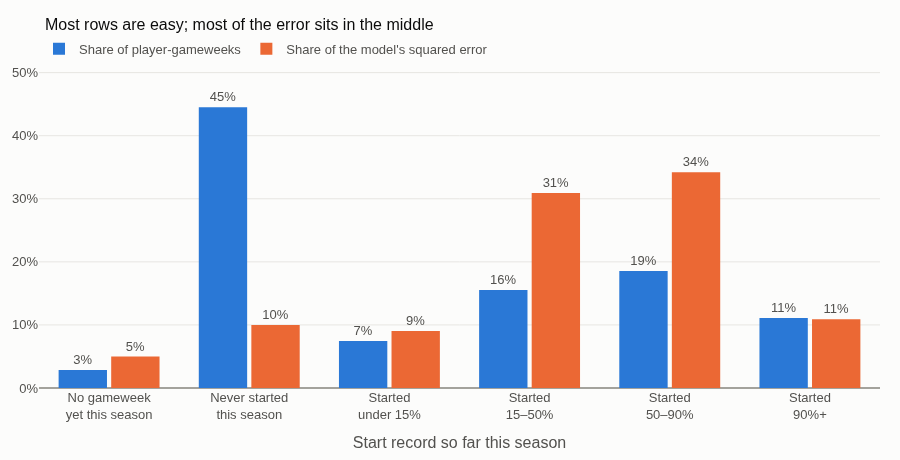

In [15]:
bands = pd.DataFrame(perf["by_band"])
long = bands.melt(id_vars="group", value_vars=["share_of_rows", "share_of_squared_error_logistic"],
                  var_name="measure", value_name="share")
long["group"] = long["group"].map({
    "No gameweek yet this season": "No gameweek<br>yet this season", "Never started this season": "Never started<br>this season",
    "Started under 15%": "Started<br>under 15%", "Started 15-50%": "Started<br>15–50%",
    "Started 50-90%": "Started<br>50–90%", "Started 90%+": "Started<br>90%+"})
long["measure"] = long["measure"].map({"share_of_rows": "Share of player-gameweeks",
                                       "share_of_squared_error_logistic": "Share of the model's squared error"})
fig = px.bar(long, x="group", y="share", color="measure", barmode="group",
             text=long["share"].map("{:.0%}".format),
             color_discrete_map={"Share of player-gameweeks": BLUE, "Share of the model's squared error": ORANGE},
             title="Most rows are easy; most of the error sits in the middle")
fig.update_traces(textposition="outside", cliponaxis=False, marker_line_width=0)
fig.update_xaxes(title="Start record so far this season", tickangle=0)
fig.update_yaxes(title=None, tickformat=".0%", range=[0, 0.52])
fig.update_layout(height=460, width=900, bargap=0.25, bargroupgap=0.08,
                  legend=dict(title=None, orientation="h", y=1.08, x=0))
fig

What the breakdown shows:

- **Players who have never started this season are easy.** They are about 45% of all player-gameweeks, start about 2% of the time, and the model's Brier on them is 0.018. They account for only 10% of its squared error. Pooled into the overall score, they pull it down without saying anything about the hard decisions.
- **Established regulars are easier than the middle, but not trivial.** Players who have started 90% or more of their games still miss about one start in eight, mostly through injury, suspension or rotation. Their Brier is 0.077, and they are 11% of rows and 11% of the error. Catching those misses is where the availability flag earns its place.
- **The middle is where the difficulty is.** Players who have started between 15% and 90% of their games are 34% of rows but 65% of the model's squared error.
- **A small hard group hides inside Deep:** players with no gameweek yet this season (mostly gameweek 1, before any record exists) start 29% of the time. They are 3% of rows and 5% of the error.

That is why results are reported by stratum, with the **Rotation** stratum (15–50%) as the headline alongside the overall score: it is the group whose starts are closest to a coin toss and where a good probability most changes FPL decisions.

## 9. Historical evaluation

A **chronological historical development evaluation**, not a final independent test (both test seasons informed the feature choice):

| Test season | Trained on |
|---|---|
| 2024-25 | 2023-24 (C validated on its last quarter) |
| 2025-26 | 2023-24 and 2024-25 (C validated on 2024-25) |

**The benchmark** is deliberately simple: a lookup table keyed on one fact, whether the player started his previous gameweek at his current club. For each training window it records the share of player-gameweeks in each cell that led to a start, and predicts that share for every player in the cell:

In [16]:
lookup = []
for test_season, fold in study["naive_lookup"].items():
    for cell in fold["cells"]:
        lookup.append({"test season": test_season, "trained on": ", ".join(fold["train_seasons"]),
                       "previous gameweek": cell["cell"], "predicted P(start)": cell["p_start"],
                       "training rows": cell["n"]})
pd.DataFrame(lookup).set_index(["test season", "trained on", "previous gameweek"]).style.format(
    {"predicted P(start)": "{:.1%}", "training rows": "{:,}"})

In words, and almost identically in both folds:

- **Started last gameweek → about 80%.** Four in five players who started one gameweek started the next.
- **Did not start last gameweek → about 8%.** This cell mixes benched regulars with squad players who never start, and the never-starters dominate it.
- **First gameweek at his club → about 19%.** A new signing with no previous gameweek at the club.

Every player in a cell gets the same number. That makes the benchmark well calibrated by construction, because its predictions *are* observed averages, but blunt: a first-choice striker who missed one match with a knock gets the same 8% as a youth player who has never been near the team, and a regular who started last week but has since been flagged injured still gets 80%. The logistic model's job is to separate exactly those players.

In [17]:
rows = []
blocks = [("overall", history["overall"])] + list(history["by_test_season"].items())
for window, block in blocks:
    for name, label in [("naive", "Started-last-week baseline"), ("logistic", "Logistic v1")]:
        m = block[name]
        rows.append({"window": window, "model": label, "Brier": m["brier"],
                     "Rotation Brier": m["by_stratum"]["Rotation"]["brier"],
                     "calibration slope": m["calibration"]["slope"], "ECE": m["calibration"]["ece"],
                     "Brier improvement": block["relative_brier_improvement"] if name == "logistic" else None,
                     "Rotation improvement": block["relative_rotation_brier_improvement"] if name == "logistic" else None})
pd.DataFrame(rows).set_index(["window", "model"]).style.format(
    {"Brier": "{:.4f}", "Rotation Brier": "{:.4f}", "calibration slope": "{:.3f}", "ECE": "{:.4f}",
     "Brier improvement": "{:.1%}", "Rotation improvement": "{:.1%}"}, na_rep="")

The interpretable logistic model materially outperforms the "started last week" baseline: about **25% lower Brier overall and 19% lower in the Rotation stratum**, where starting uncertainty matters most. The gain is similar in both seasons.

The baseline has the lower ECE. That is expected: it is a two-cell lookup table, so it is almost perfectly calibrated by construction, but it cannot tell two players with the same last-week outcome apart.

## 10. Calibration

The **Brier score** is the mean squared error of the probabilities, so it rewards both sharp and accurate forecasts. **Calibration** checks a narrower question: of the players given a 70% chance, did about 70% actually start? Each point is one probability bin on the development test seasons, and points on the dotted diagonal are perfectly calibrated.

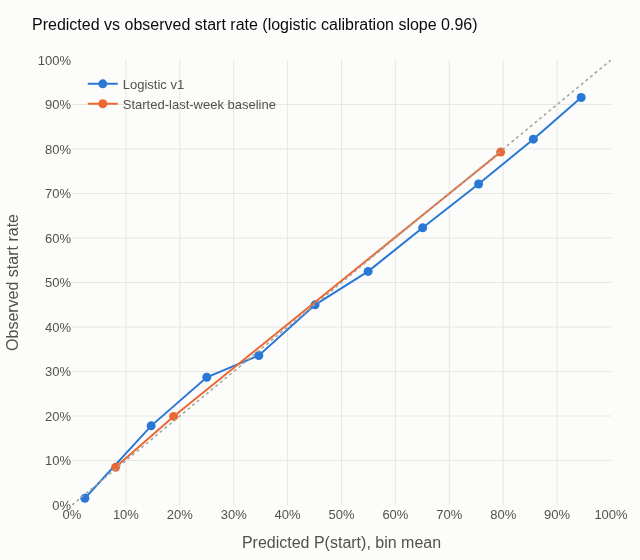

In [18]:
cal = []
for name, label in [("logistic", "Logistic v1"), ("naive", "Started-last-week baseline")]:
    for bin_ in history["overall"][name]["calibration"]["bins"]:
        cal.append({"model": label, **bin_})
cal = pd.DataFrame(cal)
slope = history["overall"]["logistic"]["calibration"]["slope"]
fig = px.line(cal, x="mean_predicted", y="mean_observed", color="model", markers=True, hover_data={"n": ":,"},
              color_discrete_map={"Logistic v1": BLUE, "Started-last-week baseline": ORANGE},
              title=f"Predicted vs observed start rate (logistic calibration slope {slope:.2f})")
fig.add_shape(type="line", x0=0, y0=0, x1=1, y1=1, line=dict(color=NEUTRAL, dash="dot", width=1.5))
fig.update_traces(line_width=2, marker_size=9)
fig.update_xaxes(title="Predicted P(start), bin mean", range=[0, 1], tickformat=".0%", dtick=0.1, zeroline=False)
fig.update_yaxes(title="Observed start rate", range=[0, 1], tickformat=".0%", dtick=0.1, zeroline=False)
fig.update_layout(height=560, width=640, legend=dict(title=None, x=0.02, y=0.98, bgcolor="rgba(0,0,0,0)"))
fig

The logistic model tracks the diagonal across the whole range, with an overall calibration slope of about **0.96** (1.0 is perfect; slightly below 1 means predictions are marginally too extreme). The baseline can only ever produce a few distinct probabilities, which is why it has just three points.

## 11. Coefficients

The frozen model's coefficients, grouped by concept:

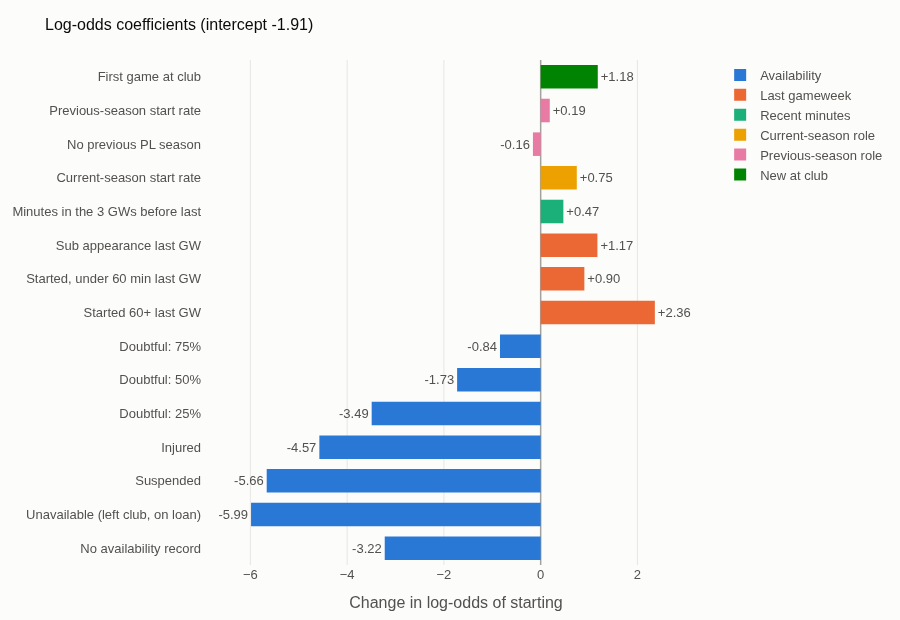

In [19]:
groups = {"availability_status": "Availability", "last_gw_role": "Last gameweek",
          "minutes_prior_3_gws": "Recent minutes", "current_season_start_rate": "Current-season role",
          "previous_season_start_rate": "Previous-season role", "no_previous_season": "Previous-season role",
          "first_game_at_club": "New at club"}
coef = pd.DataFrame({"feature": model["transformed_features"]})
coef["coefficient"] = coef["feature"].map(model["coefficients"])
coef["concept"] = coef["feature"].map(lambda f: groups[f.split("__")[0]])
coef["label"] = coef["feature"].map(LABELS)
continuous = set(model["preprocessing"]["continuous"])
coef["reads as"] = coef["feature"].map(lambda f: "per 1 SD" if f in continuous else
                                       "vs reference" if "__" in f else "flag = 1")
order = list(dict.fromkeys(groups.values()))
fig = px.bar(coef.iloc[::-1], x="coefficient", y="label", color="concept", orientation="h",
             text=coef.iloc[::-1]["coefficient"].map("{:+.2f}".format),
             hover_data={"reads as": True, "label": False},
             category_orders={"concept": order},
             color_discrete_sequence=[BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN],
             title=f'Log-odds coefficients (intercept {model["intercept"]:+.2f})')
fig.update_traces(textposition="outside", cliponaxis=False, marker_line_width=0)
fig.update_xaxes(title="Change in log-odds of starting", range=[-7, 3.5], zeroline=True, zerolinewidth=1.5)
fig.update_yaxes(title=None)
fig.update_layout(height=620, width=900, bargap=0.3, legend=dict(title=None, traceorder="normal"))
fig

How to read them:

- **Positive → higher log-odds of starting; negative → lower.** A coefficient of +0.7 multiplies the odds by $e^{0.7} \approx 2$.
- **Categorical coefficients are relative to their reference.** *Injured* (−4.6) is compared with an *available* player; *Started 60+ last GW* (+2.4) with a player who *did not play*.
- **Continuous coefficients are per standard deviation**, because those features are standardised (one SD of current-season start rate is about 0.36; of prior minutes, about 105).
- The availability levels are ordered as intuition expects, and the doubtful penalty roughly doubles from 75% to 50% to 25%.
- *Sub appearance* (+1.17) sits slightly above *Started, under 60 min* (+0.90): an early withdrawal often signals an injury or a tactical change, and the season-rate features already carry the "regular starter" signal. *First game at club* is positive because it offsets the defaults a new signing gets elsewhere (no last-GW role, average form); read it together with those.

These are **predictive associations, not causal effects.** Being flagged injured does not "cause" a lower probability through the coefficient; the flag is simply strong evidence about what the manager will do.

In [20]:
def decomposition(snapshot, code):
    e = cs.explanation(snapshot, code)
    parts = cs.contributions_by_concept(e)
    raw = {f["raw_feature"]: f["raw_value"] for f in e["features"]}
    return e, parts, raw


def contribution_chart(e, parts, title):
    df = pd.DataFrame({"component": ["Intercept"] + list(parts), "contribution": [e["intercept"]] + list(parts.values())})
    df["direction"] = df.apply(lambda r: "baseline" if r["component"] == "Intercept"
                               else "raises P(start)" if r["contribution"] > 0
                               else "lowers P(start)" if r["contribution"] < 0 else "no effect", axis=1)
    fig = px.bar(df.iloc[::-1], x="contribution", y="component", color="direction", orientation="h",
                 text=df.iloc[::-1]["contribution"].map(lambda v: "0" if v == 0 else f"{v:+.2f}"),
                 color_discrete_map={"baseline": NEUTRAL, "raises P(start)": BLUE,
                                     "lowers P(start)": RED, "no effect": NEUTRAL},
                 title=f'{title}<br><sup>logit {e["logit"]:+.2f}  →  P(start) = {e["p_start"]:.1%}</sup>')
    fig.update_traces(textposition="outside", cliponaxis=False, marker_line_width=0)
    fig.for_each_trace(lambda t: t.update(showlegend=False) if t.name == "no effect" else None)
    lo = min(df["contribution"].min(), 0) - 0.8
    hi = max(df["contribution"].max(), 0) + 0.8
    fig.update_xaxes(title="Contribution to log-odds", range=[lo, hi], zeroline=True, zerolinewidth=1.5)
    fig.update_yaxes(title=None, categoryorder="array", categoryarray=list(df["component"])[::-1])
    fig.update_layout(height=400, width=820, bargap=0.35, legend=dict(title=None, orientation="h", y=-0.2, x=0))
    return fig


def decomposition_table(e, parts, raw):
    rows = [("Intercept (reference player)", "", e["intercept"])]
    shown = {"Availability": raw["availability_status"], "Last gameweek": raw["last_gw_role"],
             "Recent minutes": raw["minutes_prior_3_gws"], "Current-season role": raw["current_season_start_rate"],
             "Previous-season role": raw["previous_season_start_rate"], "New at club": raw["first_game_at_club"]}
    for concept, value in parts.items():
        rows.append((concept, shown[concept], value))
    rows += [("Logit", "", e["logit"]), ("P(start)", "", e["p_start"])]
    out = pd.DataFrame(rows, columns=["component", "raw value", "log-odds"]).set_index("component")
    out["raw value"] = out["raw value"].map(lambda v: "missing → mean" if v is None else
                                            f"{v:.2f}" if isinstance(v, float) else v)
    return out

## 12. Example prediction: a regular starter

The example is chosen by a rule in `cs.select_regular_starter`: Erling Haaland, in the latest saved 2026-27 gameweek where he is available, started 60+ minutes the previous gameweek and has a current-season record. If no such prediction existed, it would fall back to the highest-probability player meeting the same conditions.

In [21]:
gw_r, code_r = cs.select_regular_starter(snapshots, names)
name_r, team_r = names[code_r]
e_r, parts_r, raw_r = decomposition(snapshots[gw_r], code_r)
print(f"{name_r} ({team_r}), 2026-27 GW{gw_r}")
decomposition_table(e_r, parts_r, raw_r)

Haaland (MCI), 2026-27 GW6


,raw value,log-odds
component,,
Intercept (reference player),,-1.911391
Availability,available,0.000000
Last gameweek,started_60_plus,2.360295
Recent minutes,270.00,0.855492
Current-season role,1.00,1.471416
Previous-season role,0.92,0.430873
New at club,0,0.000000
Logit,,3.206685
P(start),,0.961085


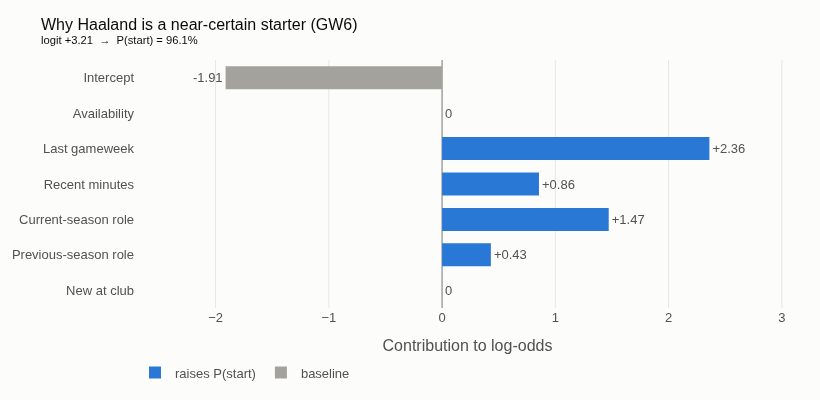

In [22]:
contribution_chart(e_r, parts_r, f"Why {name_r} is a near-certain starter (GW{gw_r})")

Every number above is read from the stored prediction; nothing is recomputed. The intercept is the reference player (available, did not play last gameweek, average on every continuous feature), who starts about 13% of the time. From there:

> Haaland receives a high starting probability because he has an established current-season role (he has started every gameweek so far), started and played 60+ minutes last week, played every minute of the three gameweeks before that, and carries no negative availability signal.

His previous-season role adds a smaller amount on top; the current season already says most of it.

## 13. Example prediction: an availability-flagged player

This example is not hand-picked. `cs.select_flagged_example` applies a documented rule to every saved 2026-27 prediction:

1. availability status is not the reference (*available*) and not *no record*;
2. the stored explanation is complete (all 15 columns present, and the contributions add up to the stored logit and probability);
3. prefer a doubtful grading over a hard state (25% → 50% → 75% → injured → suspended → unavailable), because a doubtful flag shows the model *adjusting* a probability rather than sending it to zero;
4. within that status, take the player whose *other* features alone give the highest P(start): the clearest "he would normally start" case;
5. break ties by later gameweek, then player code.

In [23]:
pick = cs.select_flagged_example(snapshots)
gw_f, code_f = pick["gameweek"], pick["code"]
name_f, team_f = names[code_f]
e_f, parts_f, raw_f = decomposition(snapshots[gw_f], code_f)
print(f"{name_f} ({team_f}), 2026-27 GW{gw_f}: status {pick['status']}; "
      f"P(start) without the availability term would be {pick['p_without_availability']:.1%}")
decomposition_table(e_f, parts_f, raw_f)

Hinshelwood (BHA), 2026-27 GW2: status doubtful_25; P(start) without the availability term would be 94.2%


,raw value,log-odds
component,,
Intercept (reference player),,-1.911391
Availability,doubtful_25,-3.493058
Last gameweek,started_60_plus,2.360295
Recent minutes,241.00,0.725683
Current-season role,1.00,1.471416
Previous-season role,0.51,0.135814
New at club,0,0.000000
Logit,,-0.711240
P(start),,0.329325


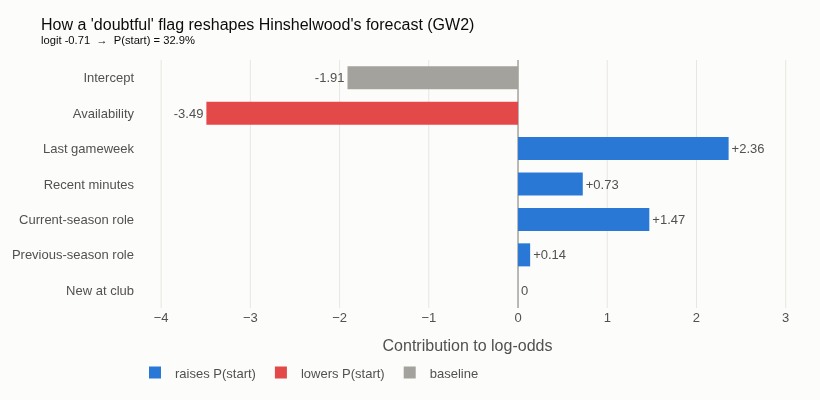

In [24]:
contribution_chart(e_f, parts_f, f"How a 'doubtful' flag reshapes {name_f}'s forecast (GW{gw_f})")

> His recent playing history says he would normally be very likely to start: he started the season's opening gameweek, played 60+ minutes in it, and played most of the minutes available in the three gameweeks before that. But FPL had flagged him doubtful with a 25% chance of playing, and that status applies the largest single contribution in the model's arithmetic, pulling the forecast from above 90% to about a third.

This is exactly the kind of question a conversational layer needs to answer ("why is he only 33%?"), and the answer is already stored with the prediction.

## 14. The two players side by side

In [25]:
side = pd.DataFrame({
    f"{name_r} (GW{gw_r})": {"Baseline / intercept": e_r["intercept"], **parts_r,
                             "Logit": e_r["logit"], "P(start)": e_r["p_start"]},
    f"{name_f} (GW{gw_f})": {"Baseline / intercept": e_f["intercept"], **parts_f,
                             "Logit": e_f["logit"], "P(start)": e_f["p_start"]},
})
side.style.format("{:+.2f}").format("{:.1%}", subset=pd.IndexSlice[["P(start)"], :])

,Haaland (GW6),Hinshelwood (GW2)
Baseline / intercept,-1.91,-1.91
Availability,+0.00,-3.49
Last gameweek,+2.36,+2.36
Recent minutes,+0.86,+0.73
Current-season role,+1.47,+1.47
Previous-season role,+0.43,+0.14
New at club,+0.00,+0.00
Logit,+3.21,-0.71
P(start),96.1%,32.9%


Both players share the same baseline and have similar playing histories. Last week's 60+ start and a full current-season record push both of them strongly up. The difference is almost entirely one row: availability. The model is not just producing two probabilities; its reasoning can be laid out term by term and compared.

## 15. 2026-27 evaluation status

The frozen model has scored every 2026-27 gameweek so far without being refitted. Two kinds of evidence are kept strictly apart:

| Gameweeks | Status |
|---|---|
| GW1–5 | retrospective temporal replay: generated after the deadline from strictly pre-cutoff inputs |
| GW6 onward | prospective frozen-model forecasts, written before the deadline |

Each snapshot records when it was generated and whether that was after the deadline:

In [26]:
pd.DataFrame([{"gameweek": gw, "deadline (UTC)": s["deadline"], "generated (UTC)": s["predicted_at"],
               "after deadline": s["generated_after_deadline"],
               "evidence type": "retrospective replay" if s["generated_after_deadline"] else "prospective forecast",
               "players": len(s["predictions"]), "Σ P(start)": sum(p["p_start"] for p in s["predictions"])}
              for gw, s in sorted(snapshots.items())]).set_index("gameweek").style.format({"Σ P(start)": "{:.1f}"})

,deadline (UTC),generated (UTC),after deadline,evidence type,players,Σ P(start)
gameweek,,,,,,
1,2026-08-21T17:30:00Z,20260924T170824Z,True,retrospective replay,599,194.2
2,2026-08-28T17:30:00Z,20260924T170853Z,True,retrospective replay,616,221.4
3,2026-09-04T17:30:00Z,20260924T170909Z,True,retrospective replay,652,226.3
4,2026-09-12T12:30:00Z,20260924T170925Z,True,retrospective replay,656,227.0
5,2026-09-18T17:30:00Z,20260924T170941Z,True,retrospective replay,658,222.2
6,2026-10-10T10:00:00Z,20260924T170957Z,False,prospective forecast,667,224.8


Scoring against actual starts will be reported separately, and the two evidence types will never be pooled into one headline number. The prospective track record builds one gameweek at a time from GW6.

## 16. Next: a LangGraph explanation layer

Every stored prediction carries, for each model column, the **raw feature value, transformed value, coefficient and contribution**, plus the **intercept, logit and probability**, and the model file carries a plain-language description of every column. That is enough for an agent to answer questions such as:

> *Why is this player's probability only 42%?*
>
> *What changed since last week?*
>
> *How much is his injury flag affecting the forecast?*
>
> *Which factor contributes most to Haaland's high P(start)?*

by reading the stored arithmetic, not by guessing. That LangGraph layer is the next engineering step, connecting this statistical model to the agentic side of the project; it is not implemented here.